In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
project_dir = '/content/drive/MyDrive/Colab Notebooks/tochijihai_hackathon/'
%cd {project_dir}

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/tochijihai_hackathon


In [1]:
import random

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import branca

import folium
from folium import GeoJson
# from folium.plugins import HeatMap
# from folium.plugins import MarkerCluster
import json

In [3]:
!pip install osmnx
import osmnx as ox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.5/107.5 kB 2.1 MB/s eta 0:00:00


In [ ]:
place_name = "Mitaka, Tokyo, Japan"
G = ox.graph_from_place(place_name, network_type='all')

In [ ]:
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)
streets_geojson = streets.to_json()

In [ ]:
def random_color():
    colormap = branca.colormap.StepColormap(
        colors=['#000000', '#74b9ff'],
        vmin=0,
        vmax=1
    )
    random_value = random.random()
    return colormap(random_value)

In [ ]:
m = folium.Map(location=[35.7027156,139.5584542], zoom_start=13, tiles='cartodbpositron')

folium.GeoJson(
    streets_geojson,
    style_function=lambda feature: {
        'fillColor': None,  # Change this dynamically if needed
        'color': random_color(),
        'weight': 2
    }
).add_to(m)

In [ ]:
m

Output hidden; open in https://colab.research.google.com to view.

Maybe there's a better way to view streets because it looks really cluttered (although it might look smoother with actual data)<br><br>

You could extend the heatmap to the houses so people know how hot their how is at a certain time of day.
- You could actually **relate this to how much air conditioning a building is going to consume**
- Estimate people's electricity budgets
- Estimate CFC/pollutant emission

In [5]:
!pip install osmapi
import osmapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.3 MB/s eta 0:00:00


In [6]:
import geopandas as gpd
from shapely.geometry import shape

In [27]:
api = osmapi.OsmApi()

# Define a bounding box (min_lat, min_lon, max_lat, max_lon)
min_lat, min_lon = 35.6912492,139.5609010
max_lat, max_lon = 35.6981441,139.5685043

# Fetch data within the bounding box
buildings = api.Map(min_lon, min_lat, max_lon, max_lat)

In [19]:
from pprint import pprint

In [28]:
node_data = []
for item in buildings:
    if item['type'] == 'node' and item['data'].get('tag', {}).get('building'):
        lat = item['data']['lat']
        lon = item['data']['lon']
        height = item['data']['tag'].get('height', None)
        node_data.append({
            'latitude': lat,
            'longitude': lon,
            'height': height
        })

In [29]:
node_data

[{'latitude': 35.695453, 'longitude': 139.562255, 'height': None}]

In [35]:
import requests
from shapely.geometry import Polygon, Point

In [32]:
# Overpass API query to get buildings with height information
overpass_url = "http://overpass-api.de/api/interpreter"
overpass_query = """
[out:json];
(
  way["building"](35.6912492, 139.5609010, 35.6981441, 139.5685043);
  node["building"](35.6912492, 139.5609010, 35.6981441, 139.5685043);
);
out body;
>;
out skel qt;
"""

response = requests.get(overpass_url, params={'data': overpass_query})
data = response.json()

In [62]:
# Convert to GeoDataFrame
elements = data['elements']
ways = [elem for elem in elements if elem['type'] == 'way']
nodes = {elem['id']: Point(elem['lon'], elem['lat']) for elem in elements if elem['type'] == 'node'}

# Extract ways (buildings)
building_data = []
for way in ways:
    tags = way.get('tags', {})
    if 'building' in tags:
        print(tags)
        coords = [(nodes[node_id].x, nodes[node_id].y) for node_id in way['nodes'] if node_id in nodes]
        if coords:
            building_data.append({
                'geometry': Polygon(coords),
                'height': tags.get('height', None),
                'building_levels': int(tags.get('building:levels', '0')),
                'data_avail': 1 if tags.get('building:levels') is not None else 0
            })

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(building_data, geometry='geometry')

{'amenity': 'community_centre', 'building': 'civic', 'name': '下連雀コミュニティセンター'}
{'building': 'yes'}
{'building': 'yes', 'source': 'Bing,2007-04'}
{'building': 'yes', 'source': 'Bing'}
{'building': 'yes', 'source': 'Bing'}
{'addr:block_number': '1', 'addr:city': '三鷹市', 'addr:country': 'JP', 'addr:full': '東京都三鷹市下連雀1-1-83', 'addr:housenumber': '83', 'addr:neighbourhood': '1丁目', 'addr:postcode': '181-0013', 'addr:province': '東京都', 'addr:quarter': '下連雀', 'alt_name:es': "Museo d'Arte Ghibli", 'building': 'yes', 'charge': '1000 ¥;700 ¥;400 ¥;100 ¥', 'contact:instagram': '100544872464694', 'contact:phone': '+81 570-055-777', 'contact:tripadvisor': '581684', 'contact:twitter': 'GhibliML', 'contact:website': 'https://www.ghibli-museum.jp/', 'contact:youtube': 'UCd1b2TUlpmDLU7YpPu889Lg', 'fee': 'yes', 'museum': 'art', 'name': '三鷹の森ジブリ美術館', 'name:en': 'Mitaka Forest Ghibli Museum', 'name:es': 'Museo Ghibli del bosque Mitaka', 'name:fr': 'Musée Ghibli de la forêt de Mitaka', 'name:it': 'Museo Ghibli 

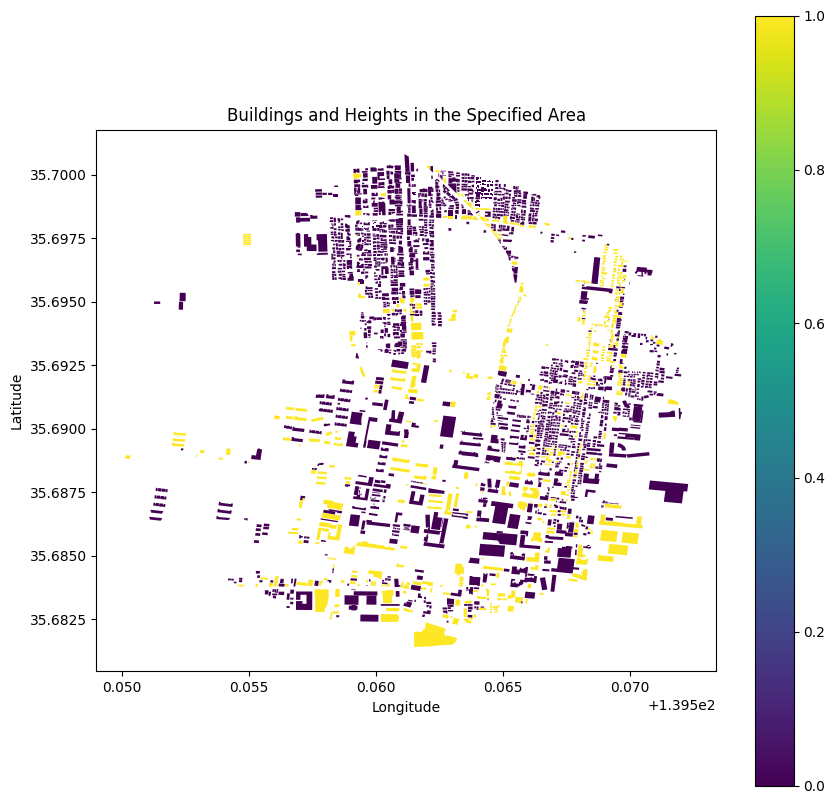

In [64]:
# Plot buildings (heights can be visualized as a color or size attribute)
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column='data_avail', cmap='viridis', legend=True, ax=ax)
plt.title('Buildings and Heights in the Specified Area')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [65]:
buildings = ox.geometries_from_place('Mitaka, Tokyo, Japan', {'building': True})
buildings.head()

<ipython-input-65-d0d492bcbeae>:1: FutureWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in the v2.0.0 release. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  buildings = ox.geometries_from_place('Mitaka, Tokyo, Japan', {'building': True})


building       name  name:ja  \
element_type osmid                                     
node         548414729    public    三鷹台市政窓口  三鷹台市政窓口   
             823495180    public     深大寺公会堂   深大寺公会堂   
             831219997    public   井の頭地区公会堂      NaN   
             1339642510      yes        NaN      NaN   
             1420765621   public  三鷹公共職業安定所      NaN   

                                           geometry        source  \
element_type osmid                                                  
node         548414729   POINT (139.58739 35.69174)           NaN   
             823495180   POINT (139.53820 35.69232)           NaN   
             831219997   POINT (139.57631 35.69696)           NaN   
             1339642510  POINT (139.58688 35.69303)  Bing,2007-03   
             1420765621  POINT (139.56225 35.69545)          KSJ2   

                                                                      note  \
element_type osmid                                                           
node         548414729                                                 NaN   
             823495180                                                 NaN   
             831219997                                                 NaN   
             1339642510                                                NaN   
             1420765621  National-Land Numerical Information (Public Fa...   

                                            note:ja  \
element_type osmid                                    
node         548414729                          NaN   
             823495180                          NaN   
             831219997                          NaN   
             1339642510                         NaN   
             1420765621  国土数値情報（公共施設データ）平成19年　国土交通省   

                                                                source_ref  \
element_type osmid                                                           
node         548414729                                                 NaN   
             823495180                                                 NaN   
             831219997                                                 NaN   
             1339642510                                                NaN   
             1420765621  http://nlftp.mlit.go.jp/ksj/jpgis/datalist/Ksj...   

                        branch brand  ... trade abandoned covered location  \
element_type osmid                    ...                                    
node         548414729     NaN   NaN  ...   NaN       NaN     NaN      NaN   
             823495180     NaN   NaN  ...   NaN       NaN     NaN      NaN   
             831219997     NaN   NaN  ...   NaN       NaN     NaN      NaN   
             1339642510    NaN   NaN  ...   NaN       NaN     NaN      NaN   
             1420765621    NaN   NaN  ...   NaN       NaN     NaN      NaN   

                        landuse roof:orientation changing_table  \
element_type osmid                                                
node         548414729      NaN              NaN            NaN   
             823495180      NaN              NaN            NaN   
             831219997      NaN              NaN            NaN   
             1339642510     NaN              NaN            NaN   
             1420765621     NaN              NaN            NaN   

                        toilets:disposal ways type  
element_type osmid                                  
node         548414729               NaN  NaN  NaN  
             823495180               NaN  NaN  NaN  
             831219997               NaN  NaN  NaN  
             1339642510              NaN  NaN  NaN  
             1420765621              NaN  NaN  NaN  

[5 rows x 136 columns]

In [72]:
buildings['height'].value_counts()

,count
height,
3,1
16,1
97.92,1
2,1
0,1
